In [3]:
%reload_ext autoreload
%autoreload 2

In [20]:
# Imports
from persistence import results as results_persistence
from persistence import splits as splits_persistence
from measures.benchmarking import driver_recovery_metric
from src import config
from src import ground_truth
import warnings
from pandas.errors import PerformanceWarning
from anndata import ImplicitModificationWarning

warnings.simplefilter("ignore", category=PerformanceWarning)
warnings.simplefilter("ignore", category=ImplicitModificationWarning)


In [5]:
SUBSAMPLE_SIZE = 10_000
TEST_SPLIT_SIZE = 40

In [7]:
results_spearman = results_persistence.load_results(
    method_name=config.METHOD_SPEARMAN,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
)

results_partial_corr = results_persistence.load_results(
    method_name=config.METHOD_PARTIAL_CORRELATION,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
)

results_mi_ksg = results_persistence.load_results(
    method_name=config.METHOD_MI_KSG,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
)

results_ig_mlp = results_persistence.load_results(
    method_name=config.METHOD_IG_MLP,
    subsample_size=SUBSAMPLE_SIZE,
    test_split_size=TEST_SPLIT_SIZE,
)

In [17]:
test_data = splits_persistence.load_test_data(
    split_name=splits_persistence.HVG_SPLIT_NAME,
    test_split_size=TEST_SPLIT_SIZE,
    subsample_size=SUBSAMPLE_SIZE
)

test_data_adt = test_data.mod["adt"]

genes_of_interest = results_spearman.index.to_list()

driver_gene_ground_truth = ground_truth.build_ground_truth(
    adt_dataset=test_data_adt,
    genes_of_interest=genes_of_interest)

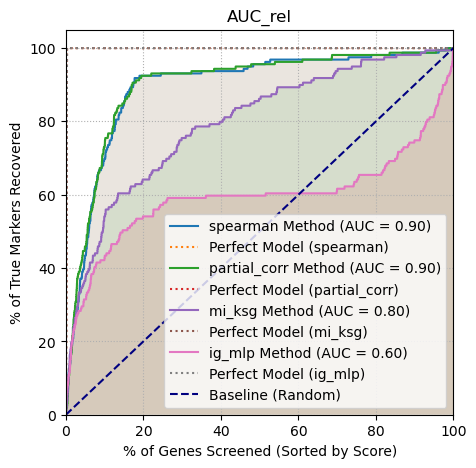

In [22]:
results = [
    results_spearman,
    results_partial_corr,
    results_mi_ksg,
    results_ig_mlp
]

driver_recovery_metric.plot(results,
                            config.METHODS,
                            driver_gene_ground_truth)